In [2]:
import pandas as pd
import sqlite3

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1', on_bad_lines='skip')

conn = sqlite3.connect('supply_chain.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

query = "SELECT COUNT(*) as Total_Rows FROM orders;"
result = pd.read_sql_query(query, conn)
print(result)

   Total_Rows
0        4010


--- Delivery Status Breakdown ---
     Delivery Status  Total_Orders
0   Advance shipping           927
1      Late delivery          2163
2  Shipping canceled           220
3   Shipping on time           700


--- Top 5 Regions with Most Late Deliveries ---
      Order Region  Late_Orders
0   Western Europe          382
1  Central America          268
2  Northern Europe          177
3          Oceania          170
4   Southeast Asia          158


/tmp/ipykernel_856/2911832089.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Late_Orders', y='Order Region', data=df_region, palette='Reds_r')


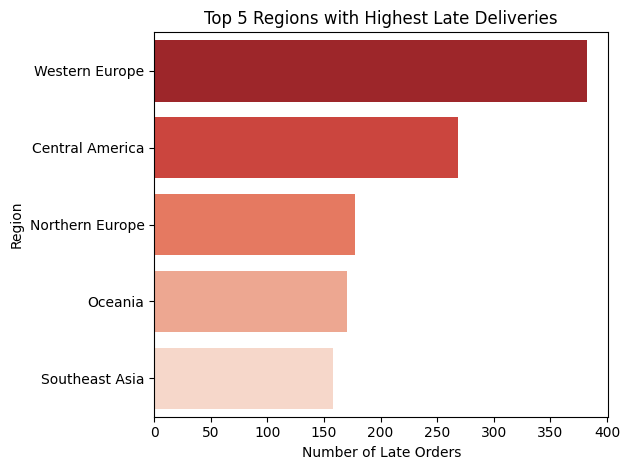

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

query_status = """
SELECT [Delivery Status], COUNT(*) as Total_Orders
FROM orders
GROUP BY [Delivery Status];
"""
df_status = pd.read_sql_query(query_status, conn)
print("--- Delivery Status Breakdown ---")
print(df_status)
print("\n")

query_region = """
SELECT [Order Region], COUNT(*) as Late_Orders
FROM orders
WHERE [Delivery Status] = 'Late delivery'
GROUP BY [Order Region]
ORDER BY Late_Orders DESC
LIMIT 5;
"""
df_region = pd.read_sql_query(query_region, conn)
print("--- Top 5 Regions with Most Late Deliveries ---")
print(df_region)

sns.barplot(x='Late_Orders', y='Order Region', data=df_region, palette='Reds_r')
plt.title('Top 5 Regions with Highest Late Deliveries')
plt.xlabel('Number of Late Orders')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('late_deliveries_by_region.png')